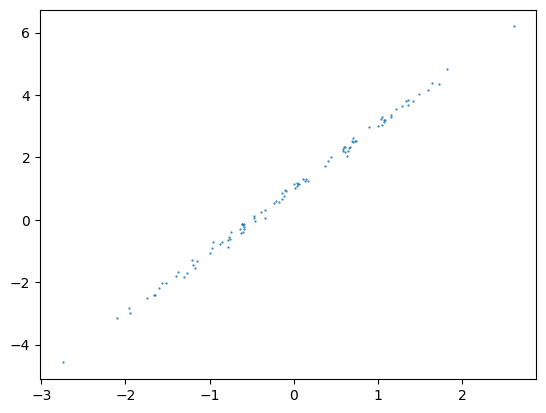

In [8]:
import torch
import matplotlib.pyplot as plt
#y = 2x + 1

X = torch.randn(100, 1)
y = 2 * X + 1 + 0.1 * torch.randn(100, 1)

plt.scatter(X, y, s=0.3)

In [9]:
w = torch.randn(1, requires_grad=True)
b = torch.randn(1, requires_grad=True)

def MSE(y_pred, y_true):
    return ((y_pred - y_true)**2).mean()

In [10]:
learning_rate = 0.1

for epoch in range(100):
    y_pred = X * w + b

    loss = MSE(y_pred, y)

    loss.backward()

    with torch.no_grad():
        w -= learning_rate * w.grad
        b -= learning_rate * b.grad

    if epoch % 10 == 0:
        print(f"epoch: {epoch}, loss: {loss.item():.4f}")

epoch: 0, loss: 3.5051
epoch: 10, loss: 0.0218
epoch: 20, loss: 3.3386
epoch: 30, loss: 1.0968
epoch: 40, loss: 1.6524
epoch: 50, loss: 2.9275
epoch: 60, loss: 0.1838
epoch: 70, loss: 3.6279
epoch: 80, loss: 0.4443
epoch: 90, loss: 2.4806


In [11]:
print("w: ", w.item())
print("b: ", b.item())

w:  1.2437940835952759
b:  -0.2466723918914795


In [12]:
import torch.nn as nn
from torchvision import transforms, datasets
from torchvision.models import resnet18, ResNet18_Weights
from torch.utils.data import DataLoader

In [13]:
transform =  transforms.Compose([
    transforms.Resize((64,64)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor()
])

In [14]:
train_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32)

model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

In [15]:
model.fc = nn.Linear(model.fc.in_features, 10)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [16]:
for epoch in range(2):
    for images, labels in train_loader:
        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    print(f"epoch: {epoch}, loss: {loss.item():.4f}")


KeyboardInterrupt: 

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

device

'cpu'

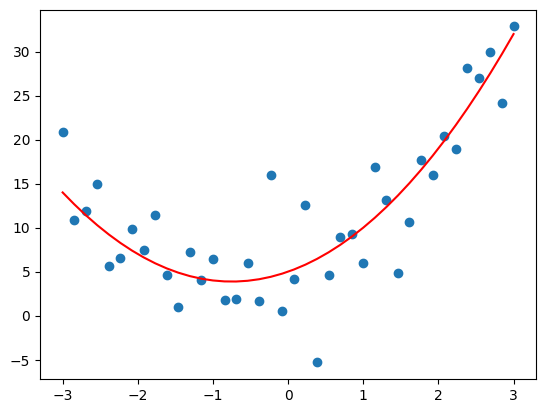

In [17]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

x = np.linspace(-3, 3, 40)
y_true = 2*x**2 + 3*x + 5
noise = np.random.normal(0, 4, size=x.shape)
y = y_true + noise

plt.scatter(x, y, label="data")
plt.plot(x, y_true, c="red", label="true function")

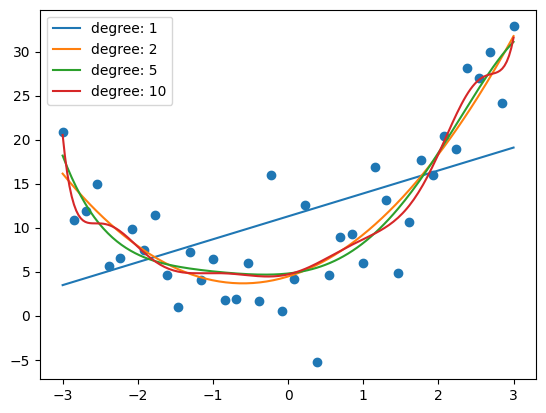

In [18]:
degrees= [1, 2, 5, 10]

plt.scatter(x, y)
X_reshaped = x.reshape(-1, 1)
X_plot = np.linspace(-3, 3, 200).reshape(-1, 1)

for d in degrees:
    poly = PolynomialFeatures(degree=d)
    X_poly = poly.fit_transform(X_reshaped)
    model = LinearRegression().fit(X_poly, y)

    y_pred = model.predict(poly.transform(X_plot))
    plt.plot(X_plot, y_pred, label=f"degree: {d}")

plt.legend()


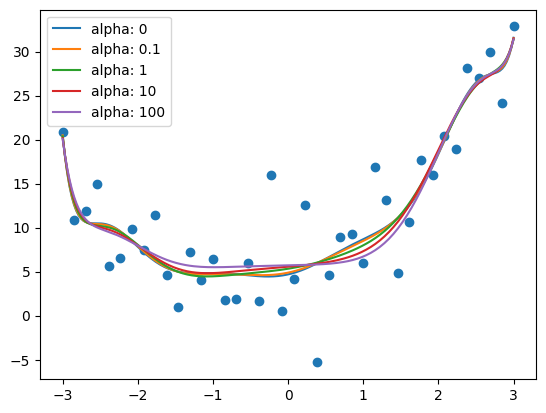

In [19]:
from sklearn.linear_model import Ridge

plt.scatter(x, y)

degree = 10
alphas = [0, 0.1, 1, 10, 100]
poly = PolynomialFeatures(degree=degree)
X_poly = poly.fit_transform(X_reshaped)

for a in alphas:

    ridge = Ridge(alpha=a).fit(X_poly, y)
    y_pred = ridge.predict(poly.transform(X_plot))

    plt.plot(X_plot, y_pred, label=f"alpha: {a}")

plt.legend()


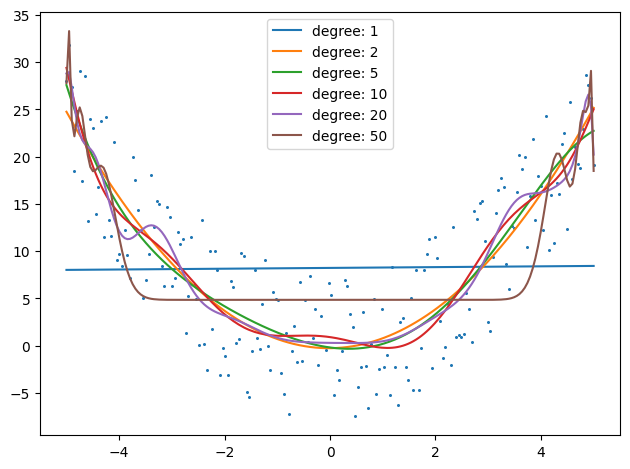

In [38]:
#import numpy as np
#import matplotlib.pyplot as plt

quadratic_X = np.linspace(-5, 5, 200).reshape(-1, 1)
noise = np.random.uniform(-8, 8, 200).reshape(-1, 1)
quadratic_y = (quadratic_X ** 2) + noise

plt.scatter(quadratic_X, quadratic_y, s=1.4)

from sklearn.pipeline import Pipeline

degrees = [1, 2, 5, 10, 20, 50]

for deg in degrees:
    pipe_quad = Pipeline([
        ("poly", PolynomialFeatures(degree=deg)),
        ("LinReg", LinearRegression())
    ])

    pipe_quad.fit(quadratic_X, quadratic_y)

    quad_y_pred = pipe_quad.predict(quadratic_X)

    plt.plot(quadratic_X, quad_y_pred, label=f"degree: {deg}")

plt.legend()
plt.tight_layout()

